# Credit Risk EDA — Xente eCommerce Transactions
**Bati Bank | Week 4 Challenge — Task 2**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

df = pd.read_csv('../data/raw/xente_transactions.csv', parse_dates=['TransactionStartTime'])
print(f'✅ Data loaded successfully')
print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')
df.head()

✅ Data loaded successfully
Rows: 95,662 | Columns: 16


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


## 1. Data Overview — Structure, Types, Shape

In [2]:
print('=== COLUMN NAMES & DATA TYPES ===')
print(df.dtypes)
print(f'\n=== DATASET SHAPE ===')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'\n=== UNIQUE CUSTOMERS ===')
print(f'Unique CustomerId: {df["CustomerId"].nunique():,}')
print(f'Unique Accounts:   {df["AccountId"].nunique():,}')
print(f'Date range: {df["TransactionStartTime"].min().date()} → {df["TransactionStartTime"].max().date()}')

=== COLUMN NAMES & DATA TYPES ===
TransactionId                           str
BatchId                                 str
AccountId                               str
SubscriptionId                          str
CustomerId                              str
CurrencyCode                            str
CountryCode                           int64
ProviderId                              str
ProductId                               str
ProductCategory                         str
ChannelId                               str
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[us, UTC]
PricingStrategy                       int64
FraudResult                           int64
dtype: object

=== DATASET SHAPE ===
Rows: 95,662
Columns: 16

=== UNIQUE CUSTOMERS ===
Unique CustomerId: 3,742
Unique Accounts:   3,633
Date range: 2018-11-15 → 2019-02-13


## 2. Summary Statistics

In [3]:
print('=== NUMERICAL SUMMARY ===')
df.describe().round(2)

=== NUMERICAL SUMMARY ===


,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,95662.00,95662.00,95662.00,95662.00
mean,256.0,6717.85,9900.58,2.26,0.00
std,0.0,123306.80,123122.09,0.73,0.04
min,256.0,-1000000.00,2.00,0.00,0.00
25%,256.0,-50.00,275.00,2.00,0.00
50%,256.0,1000.00,1000.00,2.00,0.00
75%,256.0,2800.00,5000.00,2.00,0.00
max,256.0,9880000.00,9880000.00,4.00,1.00


In [4]:
print('=== CATEGORICAL SUMMARY ===')
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'\n{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts().head(5).to_string())

=== CATEGORICAL SUMMARY ===

TransactionId: 95662 unique values
TransactionId
TransactionId_76871    1
TransactionId_73770    1
TransactionId_26203    1
TransactionId_380      1
TransactionId_28195    1

BatchId: 94809 unique values
BatchId
BatchId_67019     28
BatchId_51870     16
BatchId_113893    14
BatchId_127204    12
BatchId_116835    10

AccountId: 3633 unique values
AccountId
AccountId_4841    30893
AccountId_4249     4457
AccountId_4840     1738
AccountId_3206     1105
AccountId_318      1070

SubscriptionId: 3627 unique values
SubscriptionId
SubscriptionId_3829    32630
SubscriptionId_4429     4457
SubscriptionId_1372     1105
SubscriptionId_3087     1070
SubscriptionId_4346      965

CustomerId: 3742 unique values
CustomerId
CustomerId_7343    4091
CustomerId_3634    2085
CustomerId_647     1869
CustomerId_1096     784
CustomerId_4033     778

CurrencyCode: 1 unique values
CurrencyCode
UGX    95662

ProviderId: 6 unique values
ProviderId
ProviderId_4    38189
ProviderId_6   

## 3. Distribution of Numerical Features

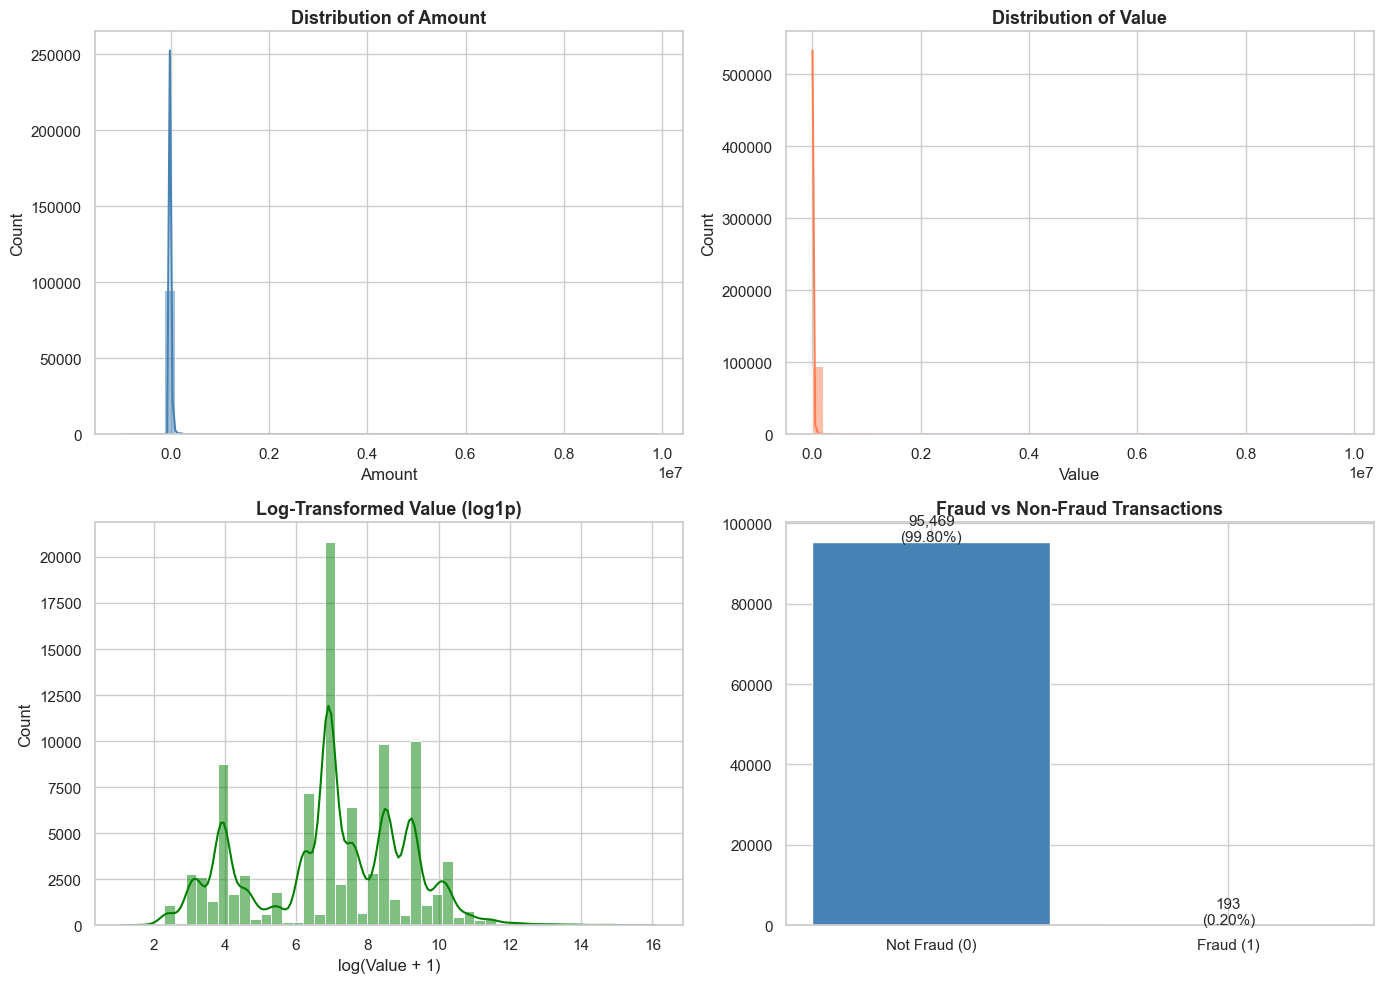

✅ Saved plot


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution
sns.histplot(df['Amount'], ax=axes[0,0], kde=True, bins=50, color='steelblue')
axes[0,0].set_title('Distribution of Amount', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Amount')

# Value distribution
sns.histplot(df['Value'], ax=axes[0,1], kde=True, bins=50, color='coral')
axes[0,1].set_title('Distribution of Value', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Value')

# Log-transformed Amount
df['log_value'] = np.log1p(df['Value'])
sns.histplot(df['log_value'], ax=axes[1,0], kde=True, bins=50, color='green')
axes[1,0].set_title('Log-Transformed Value (log1p)', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('log(Value + 1)')

# Fraud distribution
fraud_counts = df['FraudResult'].value_counts()
axes[1,1].bar(['Not Fraud (0)', 'Fraud (1)'], fraud_counts.values, color=['steelblue','tomato'])
axes[1,1].set_title('Fraud vs Non-Fraud Transactions', fontsize=13, fontweight='bold')
for i, v in enumerate(fraud_counts.values):
    axes[1,1].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.2f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/eda_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved plot')

## 4. Distribution of Categorical Features

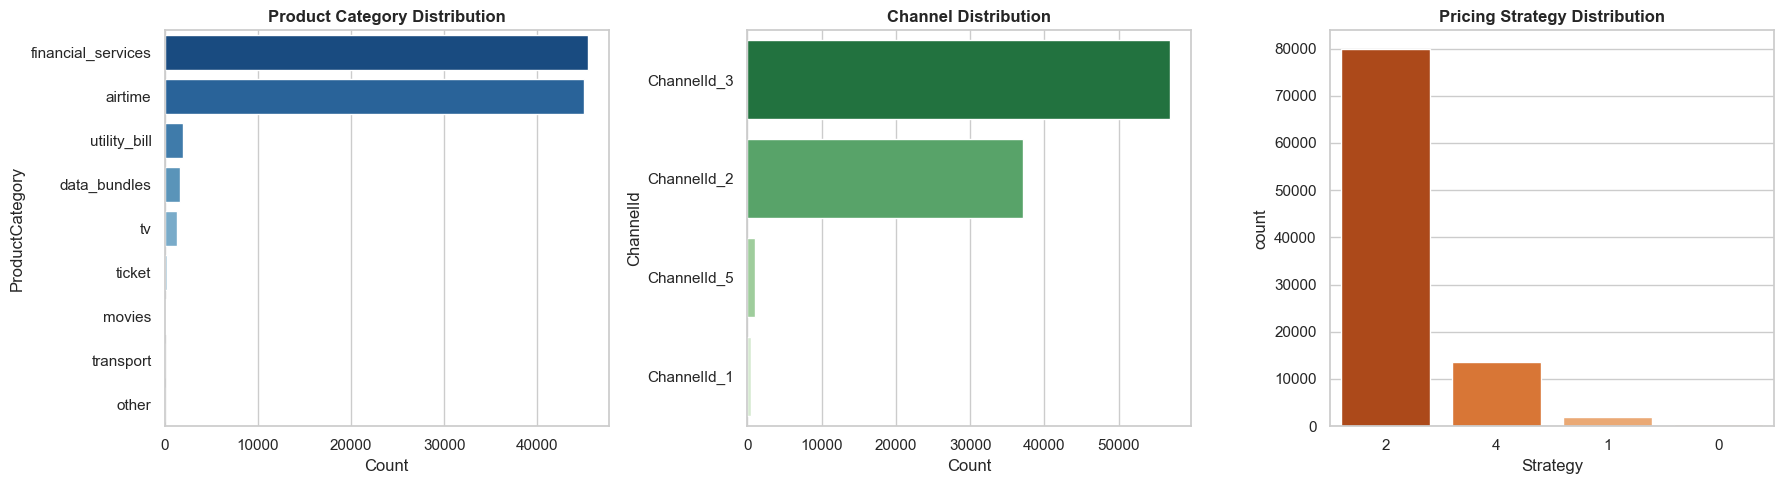

✅ Saved plot


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Product Category
cat_order = df['ProductCategory'].value_counts().index
sns.countplot(data=df, y='ProductCategory', order=cat_order, ax=axes[0], palette='Blues_r')
axes[0].set_title('Product Category Distribution', fontweight='bold')
axes[0].set_xlabel('Count')

# Channel
channel_order = df['ChannelId'].value_counts().index
sns.countplot(data=df, y='ChannelId', order=channel_order, ax=axes[1], palette='Greens_r')
axes[1].set_title('Channel Distribution', fontweight='bold')
axes[1].set_xlabel('Count')

# Pricing Strategy
ps_order = df['PricingStrategy'].value_counts().index
sns.countplot(data=df, x='PricingStrategy', order=ps_order, ax=axes[2], palette='Oranges_r')
axes[2].set_title('Pricing Strategy Distribution', fontweight='bold')
axes[2].set_xlabel('Strategy')

plt.tight_layout()
plt.savefig('../data/processed/eda_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved plot')

## 5. Correlation Analysis

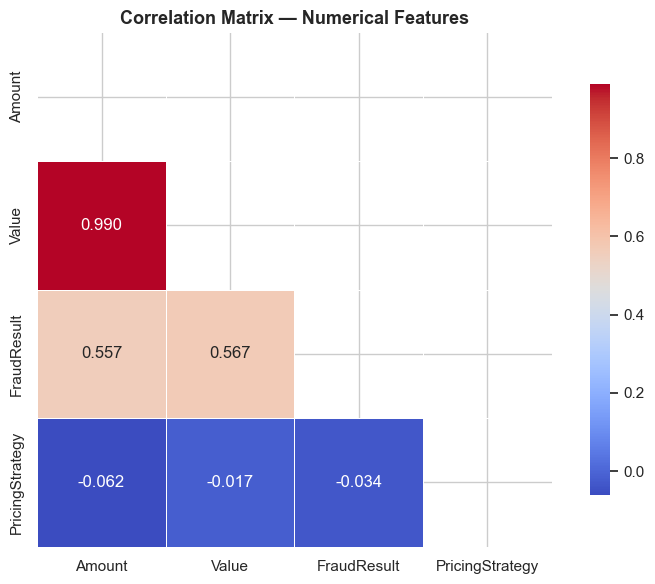

✅ Saved plot

Correlation with FraudResult:
FraudResult        1.000000
Value              0.566739
Amount             0.557370
PricingStrategy   -0.033821
Name: FraudResult, dtype: float64


In [7]:
num_df = df[['Amount', 'Value', 'FraudResult', 'PricingStrategy']].copy()

plt.figure(figsize=(8, 6))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', mask=mask,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved plot')
print('\nCorrelation with FraudResult:')
print(corr['FraudResult'].sort_values(ascending=False))

## 6. Missing Value Analysis

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print('=== MISSING VALUES PER COLUMN ===')
print(missing_df.to_string())

if missing.sum() == 0:
    print('\n✅ No missing values found in the dataset!')
else:
    print(f'\n⚠️  Total missing values: {missing.sum():,}')
    cols_with_missing = missing_df[missing_df["Missing Count"] > 0]
    print(cols_with_missing)

=== MISSING VALUES PER COLUMN ===
                      Missing Count  Missing %
TransactionId                     0        0.0
BatchId                           0        0.0
AccountId                         0        0.0
SubscriptionId                    0        0.0
CustomerId                        0        0.0
CurrencyCode                      0        0.0
CountryCode                       0        0.0
ProviderId                        0        0.0
ProductId                         0        0.0
ProductCategory                   0        0.0
ChannelId                         0        0.0
Amount                            0        0.0
Value                             0        0.0
TransactionStartTime              0        0.0
PricingStrategy                   0        0.0
FraudResult                       0        0.0
log_value                         0        0.0

✅ No missing values found in the dataset!


## 7. Outlier Detection

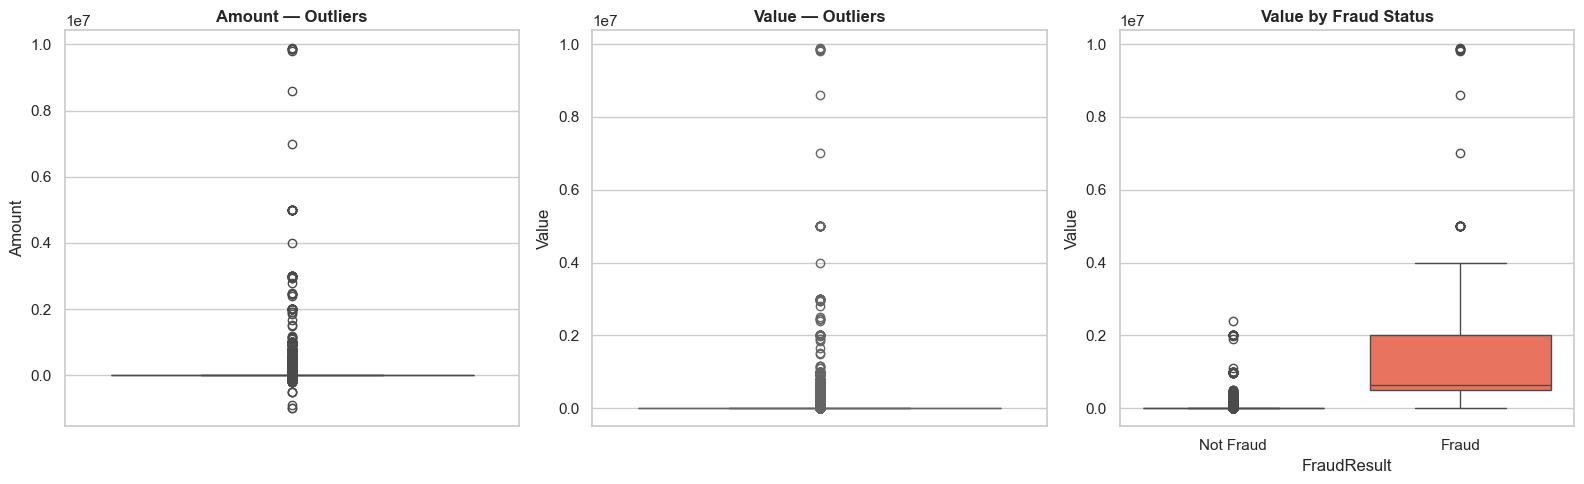

Amount: 24,441 outliers (25.55%)
Value: 9,021 outliers (9.43%)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Amount boxplot
sns.boxplot(y=df['Amount'], ax=axes[0], color='steelblue')
axes[0].set_title('Amount — Outliers', fontweight='bold')

# Value boxplot
sns.boxplot(y=df['Value'], ax=axes[1], color='coral')
axes[1].set_title('Value — Outliers', fontweight='bold')

# Amount by Fraud
sns.boxplot(data=df, x='FraudResult', y='Value', ax=axes[2],
            palette={'0': 'steelblue', '1': 'tomato'})
axes[2].set_title('Value by Fraud Status', fontweight='bold')
axes[2].set_xticklabels(['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.savefig('../data/processed/eda_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# IQR-based outlier count
for col in ['Amount', 'Value']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'{col}: {len(outliers):,} outliers ({len(outliers)/len(df)*100:.2f}%)')

## 8. Transaction Patterns Over Time

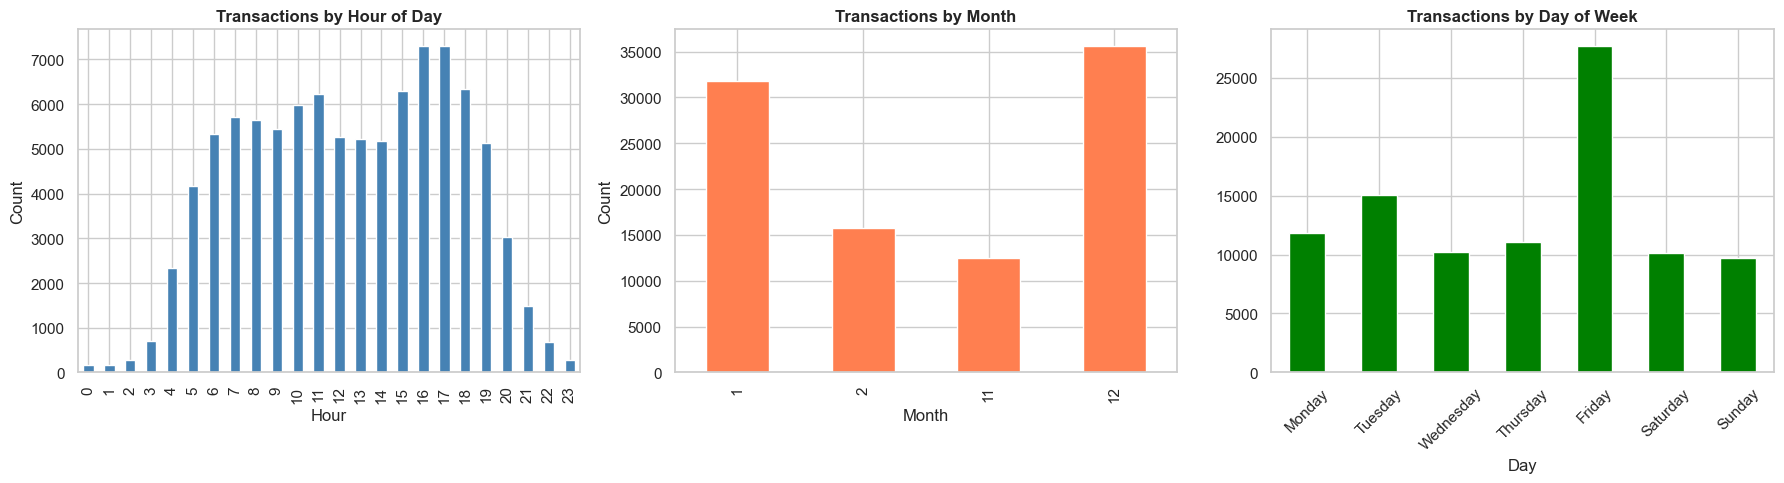

✅ Saved plot


In [10]:
df['hour'] = df['TransactionStartTime'].dt.hour
df['month'] = df['TransactionStartTime'].dt.month
df['dayofweek'] = df['TransactionStartTime'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Transactions by hour
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Transactions by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

# Transactions by month
df['month'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Transactions by Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')

# Transactions by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['dayofweek'].value_counts().reindex(day_order).plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Transactions by Day of Week', fontweight='bold')
axes[2].set_xlabel('Day')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/eda_time_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved plot')

## 9. Fraud Analysis by Category and Channel

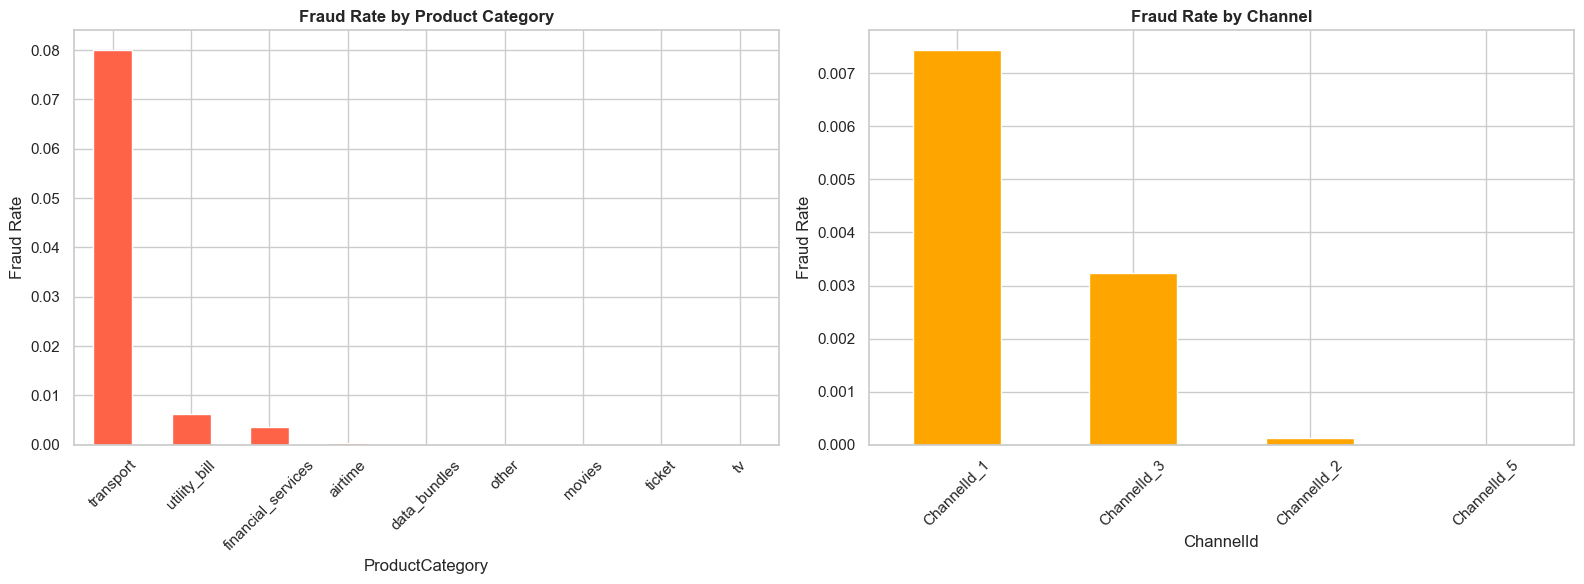

✅ Saved plot


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate by product category
fraud_by_cat = df.groupby('ProductCategory')['FraudResult'].mean().sort_values(ascending=False)
fraud_by_cat.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Fraud Rate by Product Category', fontweight='bold')
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=45)

# Fraud rate by channel
fraud_by_channel = df.groupby('ChannelId')['FraudResult'].mean().sort_values(ascending=False)
fraud_by_channel.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Fraud Rate by Channel', fontweight='bold')
axes[1].set_ylabel('Fraud Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/eda_fraud_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved plot')

## 10. Top 5 Key Insights

In [12]:
fraud_rate = df['FraudResult'].mean() * 100
top_category = df['ProductCategory'].value_counts().index[0]
top_channel = df['ChannelId'].value_counts().index[0]
peak_hour = df['hour'].value_counts().index[0]
amount_skew = df['Amount'].skew()

print('=' * 60)
print('TOP 5 KEY INSIGHTS')
print('=' * 60)
print(f'''
1. SEVERE CLASS IMBALANCE
   Fraud rate is only {fraud_rate:.2f}% of all transactions.
   This means models must use class-weight balancing or
   resampling (SMOTE) — accuracy alone is misleading.

2. DOMINANT PRODUCT CATEGORY
   "{top_category}" is the most common product category.
   Feature engineering should capture per-category risk.

3. CHANNEL CONCENTRATION
   "{top_channel}" is the most used channel.
   Channel behavior is a strong signal for RFM profiling.

4. HIGHLY SKEWED TRANSACTION AMOUNTS
   Amount skewness = {amount_skew:.2f} (right-skewed).
   Log transformation is necessary before model training.

5. PEAK TRANSACTION HOUR
   Most transactions happen at hour {peak_hour}:00.
   Time-of-day features will add predictive value to the model.
''')

TOP 5 KEY INSIGHTS

1. SEVERE CLASS IMBALANCE
   Fraud rate is only 0.20% of all transactions.
   This means models must use class-weight balancing or
   resampling (SMOTE) — accuracy alone is misleading.

2. DOMINANT PRODUCT CATEGORY
   "financial_services" is the most common product category.
   Feature engineering should capture per-category risk.

3. CHANNEL CONCENTRATION
   "ChannelId_3" is the most used channel.
   Channel behavior is a strong signal for RFM profiling.

4. HIGHLY SKEWED TRANSACTION AMOUNTS
   Amount skewness = 51.10 (right-skewed).
   Log transformation is necessary before model training.

5. PEAK TRANSACTION HOUR
   Most transactions happen at hour 16:00.
   Time-of-day features will add predictive value to the model.



## Summary

The EDA reveals that this dataset is heavily imbalanced (very few fraudulent transactions), transaction amounts are right-skewed requiring log transformation, and customer behavior varies significantly by product category and channel. These insights directly guide the feature engineering choices in Tasks 3 and 4.